In [4]:
import tensorflow as tf
from tensorflow.keras import models, layers
import matplotlib.pyplot as plt
from sklearn import metrics
from google.colab import drive

In [5]:
IMAGE_H= 224
IMAGE_W=224
BATCH_SIZE = 32
channels = 3
epochs= 50

In [7]:
drive.mount('/content/drive')

Mounted at /content/drive


In [9]:
dataset_directory = '/content/drive/MyDrive/not_augmented/enhanced_dataset'
dataset = tf.keras.preprocessing.image_dataset_from_directory(
    dataset_directory,
    shuffle=True,
    image_size=(IMAGE_H, IMAGE_W),
    batch_size=BATCH_SIZE
)

Found 696 files belonging to 2 classes.


In [10]:
import tensorflow as tf
import os

# Constants
IMAGE_H = 224
IMAGE_W = 224
BATCH_SIZE = 32
SEED = 123

# Get the number of total images in the dataset
image_count = sum([len(files) for r, d, files in os.walk(dataset_directory) if files])
print(f"Total images found: {image_count}")

# Compute how many images go into each split
train_image_count = int(0.8 * image_count)
val_image_count = int(0.1 * image_count)
test_image_count = image_count - train_image_count - val_image_count

print(f"Training images: {train_image_count}")
print(f"Validation images: {val_image_count}")
print(f"Test images: {test_image_count}")

# Load the full dataset
full_dataset = tf.keras.preprocessing.image_dataset_from_directory(
    dataset_directory,
    shuffle=True,
    image_size=(IMAGE_H, IMAGE_W),
    batch_size=BATCH_SIZE,
    seed=SEED
)

# Split the dataset by batches
total_batches = len(full_dataset)
train_batches = int(0.8 * total_batches)
val_batches = int(0.1 * total_batches)
test_batches = total_batches - train_batches - val_batches

train_dataset = full_dataset.take(train_batches)
val_dataset = full_dataset.skip(train_batches).take(val_batches)
test_dataset = full_dataset.skip(train_batches + val_batches)

# Prefetch for performance
AUTOTUNE = tf.data.AUTOTUNE
train_dataset = train_dataset.prefetch(buffer_size=AUTOTUNE)
val_dataset = val_dataset.prefetch(buffer_size=AUTOTUNE)
test_dataset = test_dataset.prefetch(buffer_size=AUTOTUNE)

print(f"\nBatches:")
print(f"Training data: {train_batches} batches")
print(f"Validation data: {val_batches} batches")
print(f"Test data: {test_batches} batches")


Total images found: 696
Training images: 556
Validation images: 69
Test images: 71
Found 696 files belonging to 2 classes.

Batches:
Training data: 17 batches
Validation data: 2 batches
Test data: 3 batches


In [24]:
BATCH_SIZE = 32
IMAGE_H, IMAGE_W = 224, 224
CHANNELS = 3
N_CLASSES = 2

model = models.Sequential([
    layers.Conv2D(32, kernel_size=(5, 5), activation='relu', input_shape=(IMAGE_H, IMAGE_W, CHANNELS)),
    layers.Conv2D(32, kernel_size=(5, 5), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.40),
    layers.Conv2D(64, kernel_size=(5, 5), activation='relu'),
    layers.Conv2D(64, kernel_size=(5, 5), activation='relu'),
    layers.Conv2D(64, kernel_size=(5, 5), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.40),
    layers.Conv2D(128, kernel_size=(5, 5), activation='relu'),
    layers.Conv2D(128, kernel_size=(5, 5), activation='relu'),
    layers.Conv2D(128, kernel_size=(5, 5), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.Dense(128, activation='relu'),
    layers.Dense(64, activation='relu'),
    layers.Dense(32, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [25]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_16 (Conv2D)              │ (None, 220, 220, 32)   │         2,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 216, 216, 32)   │        25,632 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 108, 108, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 108, 108, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_18 (Conv2D)              │ (None, 104, 104, 64)   │        51,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 100, 100, 64)   │       102,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_20 (Conv2D)              │ (None, 96, 96, 64)     │       102,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 48, 48, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 48, 48, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_21 (Conv2D)              │ (None, 44, 44, 128)    │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_22 (Conv2D)              │ (None, 40, 40, 128)    │       409,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_23 (Conv2D)              │ (None, 36, 36, 128)    │       409,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 18, 18, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 41472)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 256)            │    10,617,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,968,993 (45.66 MB)

 Trainable params: 11,968,993 (45.66 MB)

 Non-trainable params: 0 (0.00 B)

In [26]:
loss_fn = tf.keras.losses.BinaryCrossentropy(from_logits=True)

In [27]:
optimizer = tf.keras.optimizers.Adam(learning_rate=0.0001)

In [28]:
model.compile(optimizer=optimizer, loss=loss_fn, metrics=['accuracy'])

In [29]:
history=model.fit(
    train_dataset,
    epochs=epochs,
    batch_size=BATCH_SIZE,
    verbose=1,
    validation_data=val_dataset,
)

Epoch 1/50


/usr/local/lib/python3.11/dist-packages/keras/src/backend/tensorflow/nn.py:780: UserWarning: "`binary_crossentropy` received `from_logits=True`, but the `output` argument was produced by a Sigmoid activation and thus does not represent logits. Was this intended?
  output, from_logits = _get_logits(


17/17 ━━━━━━━━━━━━━━━━━━━━ 60s 3s/step - accuracy: 0.5617 - loss: 3.4256 - val_accuracy: 0.7188 - val_loss: 0.6537
Epoch 2/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 31s 312ms/step - accuracy: 0.7010 - loss: 0.6083 - val_accuracy: 0.7500 - val_loss: 0.6314
Epoch 3/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 6s 363ms/step - accuracy: 0.6904 - loss: 0.6277 - val_accuracy: 0.7969 - val_loss: 0.6105
Epoch 4/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 6s 340ms/step - accuracy: 0.7125 - loss: 0.6024 - val_accuracy: 0.7031 - val_loss: 0.6506
Epoch 5/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 5s 305ms/step - accuracy: 0.7171 - loss: 0.5985 - val_accuracy: 0.6719 - val_loss: 0.6602
Epoch 6/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 6s 383ms/step - accuracy: 0.7243 - loss: 0.5985 - val_accuracy: 0.7500 - val_loss: 0.6412
Epoch 7/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 5s 308ms/step - accuracy: 0.6953 - loss: 0.6143 - val_accuracy: 0.6875 - val_loss: 0.6465
Epoch 8/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 7s 415ms/step - accuracy: 0.7269 - loss: 0.5842 - val_accuracy: 0.7344 - val_l

In [30]:
model.evaluate(test_dataset)

3/3 ━━━━━━━━━━━━━━━━━━━━ 10s 4s/step - accuracy: 0.7234 - loss: 0.6340


[0.6382041573524475, 0.7045454382896423]

In [31]:
acc= history.history['accuracy']
val_acc = history.history['val_accuracy']

loss= history.history['loss']
val_loss = history.history['val_loss']

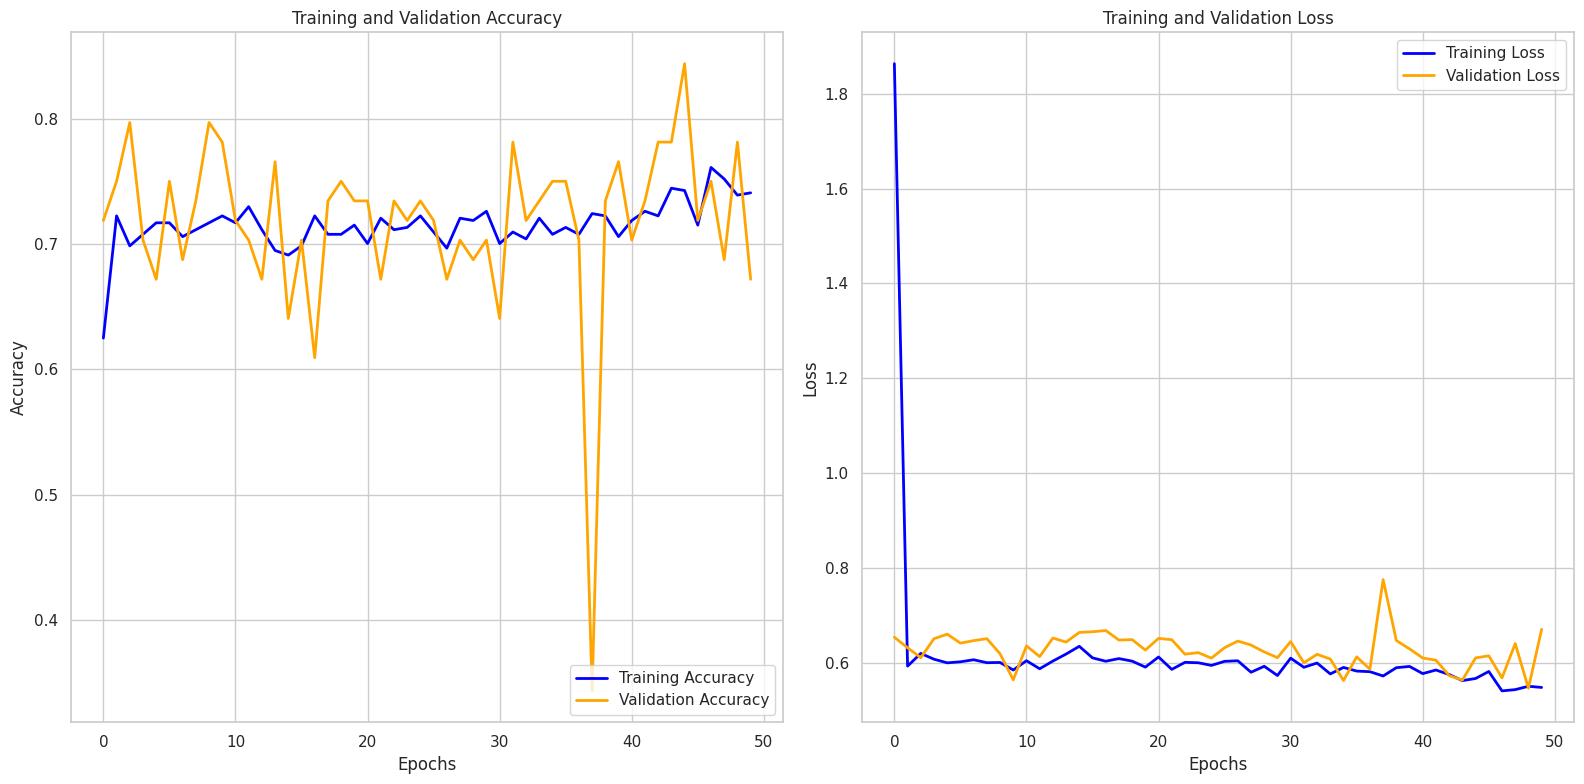

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the style
sns.set(style="whitegrid")

# Assuming you have already imported necessary libraries and have data for epochs, acc, val_acc, loss, and val_loss

plt.figure(figsize=(16, 8))  # Increase figure size for better visualization

# Subplot 1: Training and Validation Accuracy
plt.subplot(1, 2, 1)
sns.lineplot(x=range(epochs), y=acc, label='Training Accuracy', linewidth=2, color='blue')
sns.lineplot(x=range(epochs), y=val_acc, label='Validation Accuracy', linewidth=2, color='orange')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend(loc='lower right')
plt.grid(True)

# Subplot 2: Training and Validation Loss
plt.subplot(1, 2, 2)
sns.lineplot(x=range(epochs), y=loss, label='Training Loss', linewidth=2, color='blue')
sns.lineplot(x=range(epochs), y=val_loss, label='Validation Loss', linewidth=2, color='orange')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend(loc='upper right')
plt.grid(True)

plt.tight_layout()  # Adjust layout to prevent overlap
plt.show()
